# Tandem Baseline+Patch Model Inference Notebook

This notebook evaluates the tandem baseline+patch model using saved weights.

It provides:
- Validation and test metrics (precision, recall, F1, ROC-AUC, PR-AUC, balanced accuracy, MCC, Brier score)
- ROC and Precision-Recall curves
- Layer-wise CNN heatmaps for one AI and one Real sample
- Feature importance for GLCM and forensic features (group-level and per-feature permutation drop)

If any weight file is missing, the notebook skips that model and continues.

In [1]:
# If needed, uncomment and run once:
# !pip install -q torch torchvision datasets scikit-image scikit-learn pandas matplotlib tqdm

import itertools
import math
import os
import random
from typing import Dict, List, Tuple

# OpenMP duplicate-runtime workaround for some Windows Python envs (PyTorch + MKL stack).
# Keep this before numpy/torch/sklearn imports.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset, Dataset as HFDataset
from PIL import Image
from skimage.feature import graycomatrix
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Data and model configuration
# Keep a list because dataset naming can vary slightly across revisions.
DATASET_NAME_CANDIDATES = [
    "ShreyashDhoot/Ai_vs_Real",
]
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EVAL_SAMPLE_SIZE = 500
EVAL_STREAM_SCAN_LIMIT = 90000
EVAL_STREAM_SCAN_MAX = 90000

GLCM_LEVELS = 64
GLCM_DISTANCES = [1]
GLCM_ANGLES = np.deg2rad([0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5])
GLCM_FEATURE_DIM = 12 * len(GLCM_ANGLES)
FORENSIC_FEATURE_DIM = 8

NOTEBOOK_DIR = os.getcwd()
CHECKPOINT_DIR_CANDIDATES = [
    os.path.join(NOTEBOOK_DIR, "checkpoints_tandem"),
    os.path.join("ippr_project", "tandam-model", "checkpoints_tandem"),
]

CHECKPOINT_DIR = None
for p in CHECKPOINT_DIR_CANDIDATES:
    if os.path.isdir(p):
        CHECKPOINT_DIR = p
        break

if CHECKPOINT_DIR is None:
    CHECKPOINT_DIR = CHECKPOINT_DIR_CANDIDATES[0]

print(f"Checkpoint directory: {CHECKPOINT_DIR}")

MODEL_SPECS = [
    {"run_id": "model_2_patch", "name": "baseline+patch", "weight_file": "model_2_patch_best.pth"},
]

Using device: cpu
Checkpoint directory: d:\ippr\ippr_project\tandam-model\checkpoints_tandem


In [2]:
def pil_to_chw_float(img: Image.Image, size: int = IMG_SIZE) -> torch.Tensor:
    img = img.convert("RGB").resize((size, size), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))
    return torch.from_numpy(arr)


def normalize_tensor(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=x.dtype).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=x.dtype).view(3, 1, 1)
    return (x - mean) / std


def rgb_to_quantized_gray(img: Image.Image, size: int = IMG_SIZE, levels: int = GLCM_LEVELS) -> np.ndarray:
    gray = img.convert("L").resize((size, size), Image.BILINEAR)
    arr = np.asarray(gray, dtype=np.uint8)
    q = (arr.astype(np.float32) / 256.0 * levels).astype(np.int32)
    q = np.clip(q, 0, levels - 1)
    return q


def _glcm_features_from_matrix(P: np.ndarray) -> np.ndarray:
    eps = 1e-12
    P = P.astype(np.float64)
    P_sum = P.sum()
    if P_sum <= 0:
        return np.zeros(12, dtype=np.float32)
    P = P / (P_sum + eps)

    n = P.shape[0]
    i_idx = np.arange(n).reshape(-1, 1)
    j_idx = np.arange(n).reshape(1, -1)

    diff = i_idx - j_idx
    sum_ij = i_idx + j_idx

    contrast = np.sum((diff ** 2) * P)
    dissimilarity = np.sum(np.abs(diff) * P)
    homogeneity = np.sum(P / (1.0 + (diff ** 2)))

    asm = np.sum(P ** 2)
    energy = math.sqrt(max(asm, 0.0))

    p_i = P.sum(axis=1)
    p_j = P.sum(axis=0)

    mean_i = np.sum(i_idx[:, 0] * p_i)
    mean_j = np.sum(j_idx[0, :] * p_j)

    var_i = np.sum(((i_idx[:, 0] - mean_i) ** 2) * p_i)
    var_j = np.sum(((j_idx[0, :] - mean_j) ** 2) * p_j)

    std_i = math.sqrt(max(var_i, 0.0))
    std_j = math.sqrt(max(var_j, 0.0))

    corr_num = np.sum((i_idx - mean_i) * (j_idx - mean_j) * P)
    correlation = corr_num / (std_i * std_j + eps)

    entropy = -np.sum(P * np.log2(P + eps))

    centered_sum = sum_ij - mean_i - mean_j
    cluster_shade = np.sum((centered_sum ** 3) * P)
    cluster_prominence = np.sum((centered_sum ** 4) * P)

    return np.array([
        contrast, dissimilarity, homogeneity, asm, energy, correlation,
        entropy, mean_i, mean_j, var_i, cluster_shade, cluster_prominence
    ], dtype=np.float32)


def extract_glcm_96_features(img: Image.Image) -> np.ndarray:
    quant = rgb_to_quantized_gray(img, size=IMG_SIZE, levels=GLCM_LEVELS)
    glcm = graycomatrix(
        quant,
        distances=GLCM_DISTANCES,
        angles=GLCM_ANGLES,
        levels=GLCM_LEVELS,
        symmetric=True,
        normed=True,
    )

    features = []
    for a in range(glcm.shape[3]):
        P = glcm[:, :, 0, a]
        features.append(_glcm_features_from_matrix(P))
    return np.concatenate(features, axis=0).astype(np.float32)


def extract_forensic_gradient_features(img: Image.Image, size: int = IMG_SIZE) -> np.ndarray:
    gray = img.convert("L").resize((size, size), Image.BILINEAR)
    y = np.asarray(gray, dtype=np.float32) / 255.0

    gy, gx = np.gradient(y)
    g = np.stack([gx.reshape(-1), gy.reshape(-1)], axis=1)
    cov = np.cov(g, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(np.maximum(eigvals, 1e-12))[::-1]
    lam1, lam2 = float(eigvals[0]), float(eigvals[1])

    anis = (lam1 - lam2) / (lam1 + lam2 + 1e-12)
    mag = np.sqrt(gx * gx + gy * gy)
    mag_mean = float(np.mean(mag))
    mag_std = float(np.std(mag))

    residual = y - (
        np.roll(y, 1, axis=0)
        + np.roll(y, -1, axis=0)
        + np.roll(y, 1, axis=1)
        + np.roll(y, -1, axis=1)
    ) / 4.0

    r = residual.reshape(-1).astype(np.float64)
    r_centered = r - float(np.mean(r))
    r_var = float(np.mean(r_centered ** 2))
    r_fourth = float(np.mean(r_centered ** 4))
    r_kurt = r_fourth / (r_var * r_var + 1e-12)

    ry, rx = np.gradient(residual)
    rg = np.stack([rx.reshape(-1), ry.reshape(-1)], axis=1)
    rcov = np.cov(rg, rowvar=False)
    reig = np.linalg.eigvalsh(rcov)
    reig = np.sort(np.maximum(reig, 1e-12))[::-1]
    res_anis = float((reig[0] - reig[1]) / (reig[0] + reig[1] + 1e-12))

    return np.array([lam1, lam2, anis, mag_mean, mag_std, r_var, r_kurt, res_anis], dtype=np.float32)


def infer_label_column(ds_split) -> str:
    for key in ["label", "labels", "target", "class"]:
        if key in ds_split.features:
            return key
    for key, feat in ds_split.features.items():
        if key == "image":
            continue
        if hasattr(feat, "num_classes") or "int" in str(feat):
            return key
    raise ValueError("Could not infer label column.")


def compute_train_glcm_stats(hf_split, sample_size: int = 5000) -> Tuple[np.ndarray, np.ndarray]:
    n = len(hf_split)
    idxs = np.arange(n)
    if n > sample_size:
        rng = np.random.default_rng(SEED)
        idxs = rng.choice(idxs, size=sample_size, replace=False)

    feats = []
    for idx in tqdm(idxs, desc="GLCM stats", leave=False):
        ex = hf_split[int(idx)]
        img = ex["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.asarray(img))
        feats.append(extract_glcm_96_features(img))

    feats_np = np.stack(feats, axis=0).astype(np.float32)
    mean = feats_np.mean(axis=0)
    std = np.where(feats_np.std(axis=0) < 1e-6, 1.0, feats_np.std(axis=0)).astype(np.float32)
    return mean.astype(np.float32), std


def compute_train_forensic_stats(hf_split, sample_size: int = 5000) -> Tuple[np.ndarray, np.ndarray]:
    n = len(hf_split)
    idxs = np.arange(n)
    if n > sample_size:
        rng = np.random.default_rng(SEED)
        idxs = rng.choice(idxs, size=sample_size, replace=False)

    feats = []
    for idx in tqdm(idxs, desc="Forensic stats", leave=False):
        ex = hf_split[int(idx)]
        img = ex["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.asarray(img))
        feats.append(extract_forensic_gradient_features(img))

    feats_np = np.stack(feats, axis=0).astype(np.float32)
    mean = feats_np.mean(axis=0)
    std = np.where(feats_np.std(axis=0) < 1e-6, 1.0, feats_np.std(axis=0)).astype(np.float32)
    return mean.astype(np.float32), std


class AIVsRealDataset(Dataset):
    def __init__(
        self,
        hf_split,
        label_col: str,
        glcm_mean: np.ndarray = None,
        glcm_std: np.ndarray = None,
        forensic_mean: np.ndarray = None,
        forensic_std: np.ndarray = None,
    ):
        self.ds = hf_split
        self.label_col = label_col
        self.glcm_mean = glcm_mean
        self.glcm_std = glcm_std
        self.forensic_mean = forensic_mean
        self.forensic_std = forensic_std

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        ex = self.ds[idx]
        img = ex["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.asarray(img))

        cnn_x = normalize_tensor(pil_to_chw_float(img))

        glcm_x = extract_glcm_96_features(img)
        if self.glcm_mean is not None and self.glcm_std is not None:
            glcm_x = (glcm_x - self.glcm_mean) / self.glcm_std

        forensic_x = extract_forensic_gradient_features(img)
        if self.forensic_mean is not None and self.forensic_std is not None:
            forensic_x = (forensic_x - self.forensic_mean) / self.forensic_std

        y = int(ex[self.label_col])

        return {
            "image": cnn_x,
            "glcm": torch.from_numpy(glcm_x.astype(np.float32)),
            "forensic": torch.from_numpy(forensic_x.astype(np.float32)),
            "label": torch.tensor(y, dtype=torch.long),
        }

In [3]:
class ConvBlockNoPool(nn.Module):
    """Convolution block without pooling - for encoder feature extraction."""
    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.15):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout)

        self.shortcut = nn.Identity()
        if in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.act(out)
        out = self.dropout(out)
        return out


class ConvBlock(nn.Module):
    """Convolution block with pooling - for backward compatibility."""
    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.15):
        super().__init__()
        self.conv = ConvBlockNoPool(in_ch, out_ch, dropout)
        self.pool = nn.AvgPool2d(2)

    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        return out


class UpConvBlock(nn.Module):
    """Upsampling block for U-Net decoder with skip connections."""
    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.15):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = nn.Conv2d(in_ch + out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x, skip=None):
        out = self.up(x)
        if skip is not None:
            out = torch.cat([out, skip], dim=1)
        out = self.act(self.bn1(self.conv1(out)))
        out = self.bn2(self.conv2(out))
        out = self.act(out)
        out = self.dropout(out)
        return out


class ResidualMLPBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.norm1 = nn.LayerNorm(dim)
        self.fc2 = nn.Linear(dim, dim)
        self.norm2 = nn.LayerNorm(dim)
        self.act = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        identity = x
        out = self.fc1(x)
        out = self.norm1(out)
        out = self.act(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.norm2(out)
        out = out + identity
        out = self.act(out)
        return out


class GLCMEncoder(nn.Module):
    """GLCM feature encoder: 96 features -> 12x8 matrix -> 1x1 conv processing -> encoder backbone."""
    def __init__(self):
        super().__init__()
        self.conv_1x1 = nn.Conv2d(1, 8, kernel_size=1, padding=0, bias=True)
        self.bn_1x1 = nn.BatchNorm2d(8)
        self.act = nn.ReLU(inplace=True)

        self.enc1 = ConvBlock(8, 16, dropout=0.10)
        self.enc2 = ConvBlock(16, 32, dropout=0.15)
        self.enc3 = ConvBlock(32, 64, dropout=0.20)

    def forward(self, glcm_features):
        batch_size = glcm_features.shape[0]
        x = glcm_features.reshape(batch_size, 1, 12, 8)
        x = self.act(self.bn_1x1(self.conv_1x1(x)))
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = x.flatten(1)
        return x


class CNNWithTextureFusion(nn.Module):
    def __init__(self, num_classes: int = 2, glcm_dim: int = GLCM_FEATURE_DIM, forensic_dim: int = FORENSIC_FEATURE_DIM):
        super().__init__()

        self.glcm_encoder = GLCMEncoder()

        self.enc1_conv = ConvBlockNoPool(3, 32, dropout=0.10)
        self.enc1_pool = nn.AvgPool2d(2)

        self.enc2_conv = ConvBlockNoPool(32, 64, dropout=0.15)
        self.enc2_pool = nn.AvgPool2d(2)

        self.enc3_conv = ConvBlockNoPool(64, 128, dropout=0.20)
        self.enc3_pool = nn.AvgPool2d(2)

        self.enc4_conv = ConvBlockNoPool(128, 256, dropout=0.25)
        self.enc4_pool = nn.AvgPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.30),
        )

        self.dec4 = UpConvBlock(512, 256, dropout=0.25)
        self.dec3 = UpConvBlock(256, 128, dropout=0.20)
        self.dec2 = UpConvBlock(128, 64, dropout=0.15)
        self.dec1 = UpConvBlock(64, 32, dropout=0.10)

        self.final_conv = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.forensic_mlp = nn.Sequential(
            nn.Linear(forensic_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(inplace=True),
        )

        fusion_dim = 64 + 32 + 32
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def encode_fused(self, image: torch.Tensor, glcm: torch.Tensor, forensic: torch.Tensor) -> torch.Tensor:
        glcm_feat = self.glcm_encoder(glcm)

        enc1_pre = self.enc1_conv(image)
        enc1_post = self.enc1_pool(enc1_pre)

        enc2_pre = self.enc2_conv(enc1_post)
        enc2_post = self.enc2_pool(enc2_pre)

        enc3_pre = self.enc3_conv(enc2_post)
        enc3_post = self.enc3_pool(enc3_pre)

        enc4_pre = self.enc4_conv(enc3_post)
        enc4_post = self.enc4_pool(enc4_pre)

        bottleneck_out = self.bottleneck(enc4_post)

        dec4_out = self.dec4(bottleneck_out, skip=enc4_pre)
        dec3_out = self.dec3(dec4_out, skip=enc3_pre)
        dec2_out = self.dec2(dec3_out, skip=enc2_pre)
        dec1_out = self.dec1(dec2_out, skip=enc1_pre)

        cnn_feat = self.final_conv(dec1_out).flatten(1)
        forensic_feat = self.forensic_mlp(forensic)

        fused = torch.cat([glcm_feat, cnn_feat, forensic_feat], dim=1)
        return fused

    def forward(self, image: torch.Tensor, glcm: torch.Tensor, forensic: torch.Tensor):
        fused = self.encode_fused(image, glcm, forensic)
        return self.classifier(fused)

In [4]:
# Stream dataset and sample only 500 records (no full download).
def _load_streaming_split(dataset_name: str):
    # Prefer train split from stream, fallback to any available split.
    try:
        return load_dataset(dataset_name, split="train", streaming=True)
    except Exception:
        ds_dict = load_dataset(dataset_name, streaming=True)
        first_key = next(iter(ds_dict.keys()))
        return ds_dict[first_key]


def _infer_label_key_from_example(ex: dict) -> str:
    for key in ["label", "labels", "target", "class"]:
        if key in ex:
            return key
    for key, value in ex.items():
        if key == "image":
            continue
        if isinstance(value, (int, np.integer)):
            return key
    raise ValueError("Could not infer label field from streaming example.")


def _class_balanced_stream_sample(
    stream_iter,
    label_col: str,
    n_samples: int = 500,
    seed: int = 42,
    scan_limit: int =90000,
 ):
    """Reservoir-like class-balanced sampling from a streamed iterator."""
    rng = np.random.default_rng(seed)
    target_per_class = max(1, n_samples // 2)

    buffers: Dict[int, List[dict]] = {}
    seen_per_class: Dict[int, int] = {}
    total_seen = 0

    for ex in tqdm(stream_iter, total=scan_limit, desc=f"Streaming up to {scan_limit} examples", leave=False):
        total_seen += 1
        try:
            y = int(ex[label_col])
        except Exception:
            continue

        if y not in buffers:
            buffers[y] = []
            seen_per_class[y] = 0

        seen_per_class[y] += 1
        cls_seen = seen_per_class[y]
        cls_buf = buffers[y]

        if len(cls_buf) < target_per_class:
            cls_buf.append(ex)
        else:
            j = int(rng.integers(0, cls_seen))
            if j < target_per_class:
                cls_buf[j] = ex

        if total_seen >= scan_limit:
            break

    if len(buffers) < 2:
        raise RuntimeError(
            f"Only found {len(buffers)} class in first {scan_limit} streamed examples."
        )

    top_labels = sorted(buffers.keys(), key=lambda k: seen_per_class[k], reverse=True)[:2]
    sampled = list(buffers[top_labels[0]]) + list(buffers[top_labels[1]])

    if len(sampled) < n_samples:
        pool = list(buffers[top_labels[0]]) + list(buffers[top_labels[1]])
        if len(pool) > 0:
            while len(sampled) < n_samples:
                sampled.append(pool[int(rng.integers(0, len(pool)))])

    sampled = sampled[:n_samples]
    rng.shuffle(sampled)
    return sampled


stream_loaded = False
for ds_name in DATASET_NAME_CANDIDATES:
    try:
        stream_split = _load_streaming_split(ds_name)
        stream_it = iter(stream_split)
        first_ex = next(stream_it)
        label_col = _infer_label_key_from_example(first_ex)

        current_scan = EVAL_STREAM_SCAN_LIMIT
        sampled_records = None
        while current_scan <= EVAL_STREAM_SCAN_MAX:
            try:
                merged_stream = itertools.chain([first_ex], stream_it)
                sampled_records = _class_balanced_stream_sample(
                    merged_stream,
                    label_col=label_col,
                    n_samples=EVAL_SAMPLE_SIZE,
                    seed=SEED,
                    scan_limit=current_scan,
                )
                break
            except RuntimeError as e:
                print(f"Sampling retry @ scan_limit={current_scan} failed: {e}")
                current_scan *= 2
                # restart iterator for next attempt
                stream_split = _load_streaming_split(ds_name)
                stream_it = iter(stream_split)
                first_ex = next(stream_it)

        if sampled_records is None:
            raise RuntimeError(
                f"Could not get class-balanced sample up to scan_limit={EVAL_STREAM_SCAN_MAX}"
            )

        DATASET_NAME = ds_name
        stream_loaded = True
        break
    except Exception as e:
        print(f"Failed streaming from {ds_name}: {e}")

if not stream_loaded:
    raise RuntimeError("Could not stream from any dataset candidate.")

# Build an in-memory HF dataset from sampled stream records only.
sampled_ds = HFDataset.from_list(sampled_records)

# 50/50 split for threshold tuning (val) and reporting (test).
split = sampled_ds.train_test_split(test_size=0.5, seed=SEED, shuffle=True)
ds_val = split["train"]
ds_test = split["test"]

try:
    feat = sampled_ds.features[label_col]
    num_classes = getattr(feat, "num_classes", None) or len(set(sampled_ds[label_col]))
except Exception:
    num_classes = len(set(sampled_ds[label_col]))

print(f"Dataset source: {DATASET_NAME} (streaming)")
print(f"Using sampled records only: total={len(sampled_ds)} | val={len(ds_val)} | test={len(ds_test)}")
print(f"label_col={label_col} | classes={num_classes}")

# For this quick-eval setup, normalize handcrafted features using val split samples only.
glcm_mean, glcm_std = compute_train_glcm_stats(ds_val, sample_size=min(len(ds_val), 500))
forensic_mean, forensic_std = compute_train_forensic_stats(ds_val, sample_size=min(len(ds_val), 500))

val_ds = AIVsRealDataset(
    ds_val,
    label_col=label_col,
    glcm_mean=glcm_mean,
    glcm_std=glcm_std,
    forensic_mean=forensic_mean,
    forensic_std=forensic_std,
)
test_ds = AIVsRealDataset(
    ds_test,
    label_col=label_col,
    glcm_mean=glcm_mean,
    glcm_std=glcm_std,
    forensic_mean=forensic_mean,
    forensic_std=forensic_std,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

Streaming up to 90000 examples:   0%|          | 0/90000 [00:00<?, ?it/s]

Dataset source: ShreyashDhoot/Ai_vs_Real (streaming)
Using sampled records only: total=500 | val=250 | test=250
label_col=label | classes=2


GLCM stats:   0%|          | 0/250 [00:00<?, ?it/s]

Forensic stats:   0%|          | 0/250 [00:00<?, ?it/s]

In [5]:
def predict_probs(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    ys, probs = [], []
    with torch.no_grad():
        for batch in loader:
            x_img = batch["image"].to(device)
            x_glcm = batch["glcm"].to(device)
            x_forensic = batch["forensic"].to(device)
            y = batch["label"].to(device)

            logits = model(x_img, x_glcm, x_forensic)
            pos_prob = torch.softmax(logits, dim=1)[:, 1]

            ys.append(y.cpu().numpy())
            probs.append(pos_prob.cpu().numpy())

    return np.concatenate(ys), np.concatenate(probs)


def tune_threshold_for_f1(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx])


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> Dict[str, float]:
    y_pred = (y_prob >= threshold).astype(np.int64)

    try:
        roc_auc = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        roc_auc = float("nan")

    try:
        pr_auc = float(average_precision_score(y_true, y_prob))
    except ValueError:
        pr_auc = float("nan")

    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier": float(brier_score_loss(y_true, y_prob)),
    }

    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm, y_pred


def evaluate_model_on_val_and_test(model: nn.Module, model_name: str):
    y_val, p_val = predict_probs(model, val_loader)
    best_threshold = tune_threshold_for_f1(y_val, p_val)
    val_metrics, val_cm, val_pred = compute_metrics(y_val, p_val, best_threshold)

    y_test, p_test = predict_probs(model, test_loader)
    test_metrics, test_cm, test_pred = compute_metrics(y_test, p_test, best_threshold)

    return {
        "model": model_name,
        "threshold": best_threshold,
        "val": {
            "y_true": y_val,
            "y_prob": p_val,
            "y_pred": val_pred,
            "metrics": val_metrics,
            "confusion_matrix": val_cm,
        },
        "test": {
            "y_true": y_test,
            "y_prob": p_test,
            "y_pred": test_pred,
            "metrics": test_metrics,
            "confusion_matrix": test_cm,
        },
    }


def summarize_results(results: Dict[str, Dict]) -> pd.DataFrame:
    rows = []
    for run_id, out in results.items():
        row = {"run_id": run_id, "model": out["model"]}
        for split in ["val", "test"]:
            for k, v in out[split]["metrics"].items():
                row[f"{split}_{k}"] = v
        rows.append(row)
    df = pd.DataFrame(rows)
    if not df.empty:
        sort_col = "test_f1" if "test_f1" in df.columns else df.columns[-1]
        df = df.sort_values(sort_col, ascending=False).reset_index(drop=True)
    return df

In [6]:
loaded_models: Dict[str, nn.Module] = {}
missing_models: List[str] = []
bad_models: List[str] = []


def _load_checkpoint_state_dict(weight_path: str, device: torch.device):
    """Robust checkpoint loader for PyTorch 2.6+ and older checkpoint formats."""
    try:
        ckpt = torch.load(weight_path, map_location=device, weights_only=True)
    except Exception as e1:
        print(f"  [WARN] weights_only=True failed for {os.path.basename(weight_path)}: {e1}")
        ckpt = torch.load(weight_path, map_location=device, weights_only=False)

    if isinstance(ckpt, dict):
        if "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
            return ckpt["state_dict"]
        if "model_state_dict" in ckpt and isinstance(ckpt["model_state_dict"], dict):
            return ckpt["model_state_dict"]
        return ckpt

    raise ValueError(f"Unsupported checkpoint structure in {weight_path}")


for spec in MODEL_SPECS:
    run_id = spec["run_id"]
    weight_path = os.path.join(CHECKPOINT_DIR, spec["weight_file"])

    if not os.path.exists(weight_path):
        missing_models.append(run_id)
        print(f"[SKIP] Missing weights for {run_id}: {weight_path}")
        continue

    try:
        model = CNNWithTextureFusion(num_classes=num_classes, glcm_dim=GLCM_FEATURE_DIM, forensic_dim=FORENSIC_FEATURE_DIM).to(device)
        state = _load_checkpoint_state_dict(weight_path, device)
        incompatible = model.load_state_dict(state, strict=False)
        model.eval()

        # These checkpoints may include training-only heads (e.g., projection head).
        ignored = list(incompatible.unexpected_keys)
        missing = list(incompatible.missing_keys)

        loaded_models[run_id] = model
        print(f"[OK] Loaded {run_id} from {weight_path}")
        if ignored:
            print(f"  [INFO] Ignored unexpected keys ({len(ignored)}): {ignored[:8]}")
        if missing:
            print(f"  [WARN] Missing model keys ({len(missing)}): {missing[:8]}")
    except Exception as e:
        bad_models.append(run_id)
        print(f"[SKIP] Failed to load {run_id} from {weight_path}: {e}")

if len(loaded_models) == 0:
    raise RuntimeError("No usable model checkpoints were loaded.")

print(f"Loaded models: {list(loaded_models.keys())}")
if missing_models:
    print(f"Missing models: {missing_models}")
if bad_models:
    print(f"Bad/corrupt checkpoints: {bad_models}")

[OK] Loaded model_2_patch from d:\ippr\ippr_project\tandam-model\checkpoints_tandem\model_2_patch_best.pth
  [INFO] Ignored unexpected keys (4): ['proj_head.0.weight', 'proj_head.0.bias', 'proj_head.2.weight', 'proj_head.2.bias']
Loaded models: ['model_2_patch']


In [7]:
all_results: Dict[str, Dict] = {}

for spec in MODEL_SPECS:
    run_id = spec["run_id"]
    if run_id not in loaded_models:
        continue

    print("\n" + "=" * 72)
    print(f"Evaluating: {run_id} ({spec['name']})")
    print("=" * 72)

    out = evaluate_model_on_val_and_test(loaded_models[run_id], model_name=spec["name"])
    all_results[run_id] = out

    print("Validation metrics:")
    for k, v in out["val"]["metrics"].items():
        print(f"  {k}: {v:.4f}")
    print("Validation confusion matrix:")
    val_cm = out["val"]["confusion_matrix"]
    print(f"     Real  AI")
    print(f"Real  {val_cm[0,0]:3d}  {val_cm[0,1]:3d}")
    print(f"AI    {val_cm[1,0]:3d}  {val_cm[1,1]:3d}")

    print("Test metrics:")
    for k, v in out["test"]["metrics"].items():
        print(f"  {k}: {v:.4f}")
    print("Test confusion matrix:")
    test_cm = out["test"]["confusion_matrix"]
    print(f"     Real  AI")
    print(f"Real  {test_cm[0,0]:3d}  {test_cm[0,1]:3d}")
    print(f"AI    {test_cm[1,0]:3d}  {test_cm[1,1]:3d}")

summary_df = summarize_results(all_results)
display(summary_df)

if all_results:
    best_run = summary_df.iloc[0]["run_id"]
    print(f"Best model by test_f1: {best_run}")


Evaluating: model_2_patch (baseline+patch)
Validation metrics:
  threshold: 0.5012
  accuracy: 0.8480
  precision: 0.8231
  recall: 0.8770
  f1: 0.8492
  balanced_accuracy: 0.8487
  mcc: 0.6977
  roc_auc: 0.9116
  pr_auc: 0.8974
  brier: 0.1496
Validation confusion matrix:
     Real  AI
Real  105   23
AI     15  107
Test metrics:
  threshold: 0.5012
  accuracy: 0.8040
  precision: 0.8110
  recall: 0.8047
  f1: 0.8078
  balanced_accuracy: 0.8040
  mcc: 0.6079
  roc_auc: 0.8993
  pr_auc: 0.8992
  brier: 0.1607
Test confusion matrix:
     Real  AI
Real   98   24
AI     25  103


,run_id,model,val_threshold,val_accuracy,val_precision,val_recall,val_f1,val_balanced_accuracy,val_mcc,val_roc_auc,...,test_threshold,test_accuracy,test_precision,test_recall,test_f1,test_balanced_accuracy,test_mcc,test_roc_auc,test_pr_auc,test_brier
0,model_2_patch,baseline+patch,0.501158,0.848,0.823077,0.877049,0.849206,0.848681,0.697719,0.911629,...,0.501158,0.804,0.811024,0.804688,0.807843,0.803983,0.607869,0.89927,0.899151,0.160729


Best model by test_f1: model_2_patch


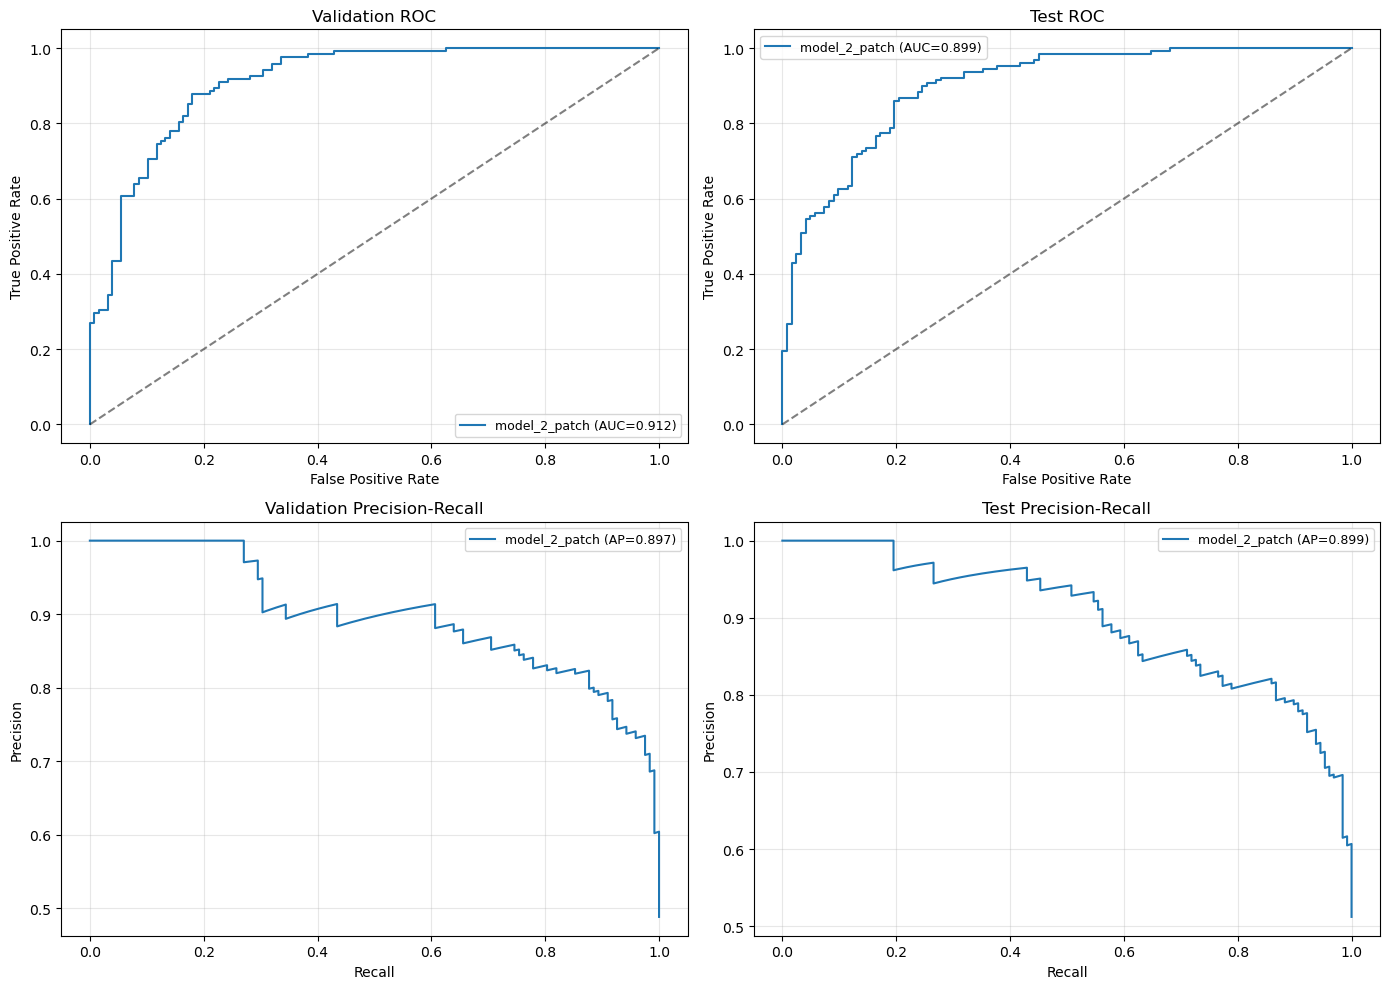

In [8]:
# ROC and PR curves for validation and test sets
if not all_results:
    raise RuntimeError("No evaluated model outputs available.")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for run_id, out in all_results.items():
    y_val = out["val"]["y_true"]
    p_val = out["val"]["y_prob"]
    y_test = out["test"]["y_true"]
    p_test = out["test"]["y_prob"]

    fpr_v, tpr_v, _ = roc_curve(y_val, p_val)
    fpr_t, tpr_t, _ = roc_curve(y_test, p_test)

    prec_v, rec_v, _ = precision_recall_curve(y_val, p_val)
    prec_t, rec_t, _ = precision_recall_curve(y_test, p_test)

    axes[0, 0].plot(fpr_v, tpr_v, label=f"{run_id} (AUC={out['val']['metrics']['roc_auc']:.3f})")
    axes[0, 1].plot(fpr_t, tpr_t, label=f"{run_id} (AUC={out['test']['metrics']['roc_auc']:.3f})")
    axes[1, 0].plot(rec_v, prec_v, label=f"{run_id} (AP={out['val']['metrics']['pr_auc']:.3f})")
    axes[1, 1].plot(rec_t, prec_t, label=f"{run_id} (AP={out['test']['metrics']['pr_auc']:.3f})")

axes[0, 0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=0.5)

axes[0, 0].set_title("Validation ROC")
axes[0, 1].set_title("Test ROC")
axes[1, 0].set_title("Validation Precision-Recall")
axes[1, 1].set_title("Test Precision-Recall")

for ax in axes.flatten():
    ax.grid(alpha=0.3)
    ax.set_xlabel("Recall" if "Precision-Recall" in ax.get_title() else "False Positive Rate")
    ax.set_ylabel("Precision" if "Precision-Recall" in ax.get_title() else "True Positive Rate")
    ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

Layer-wise heatmaps using model: model_2_patch

Label 0 (AI), sample index: 0


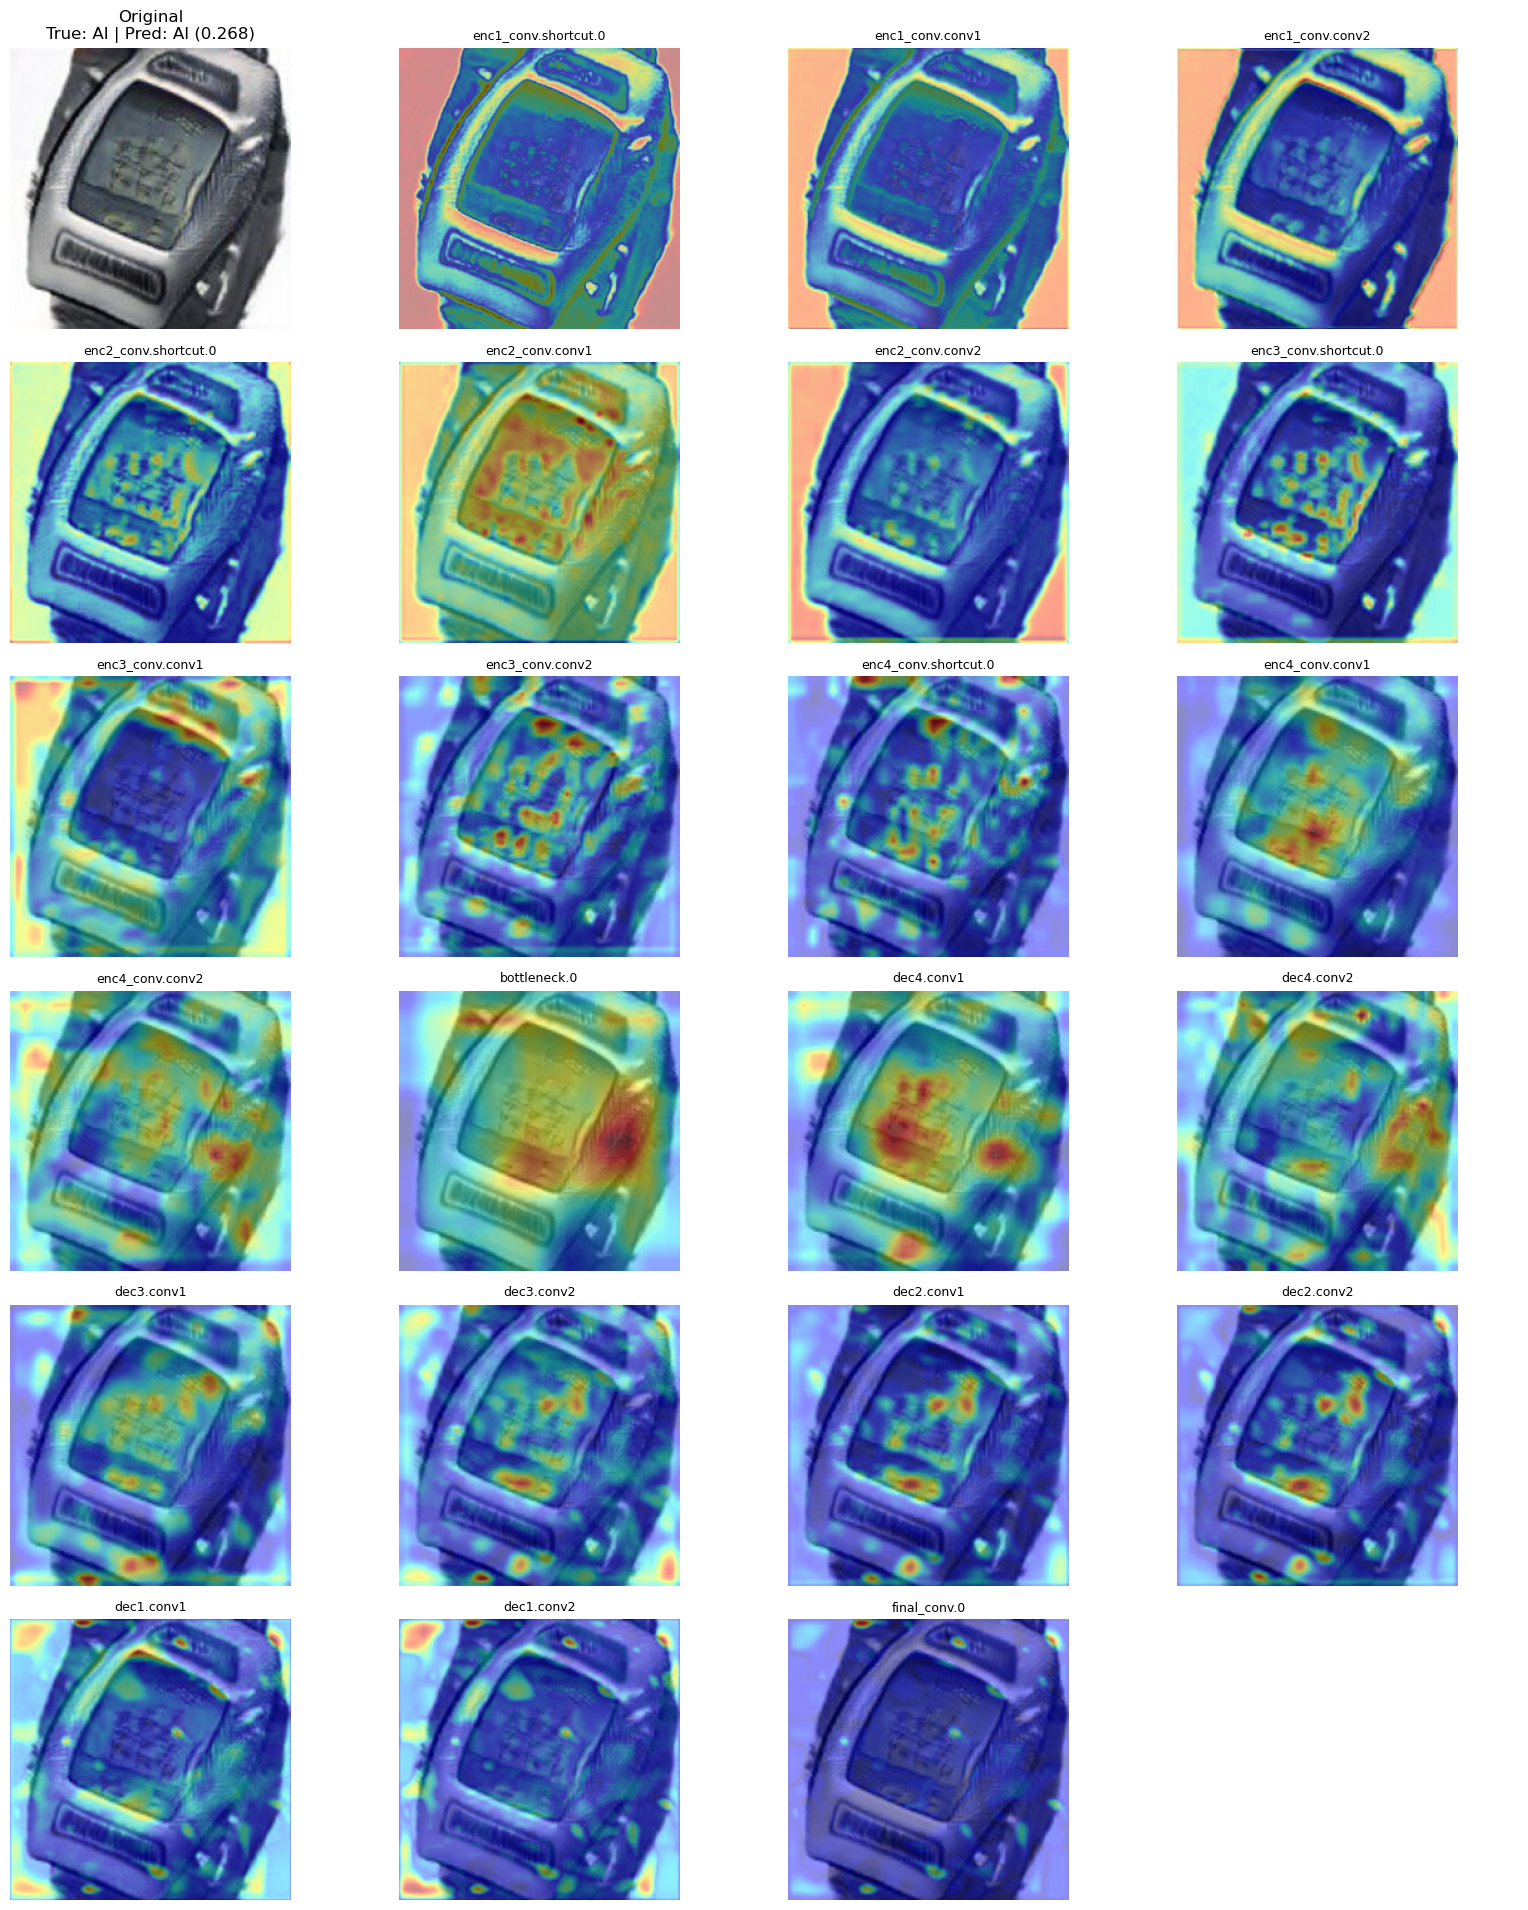


Label 1 (Real), sample index: 1


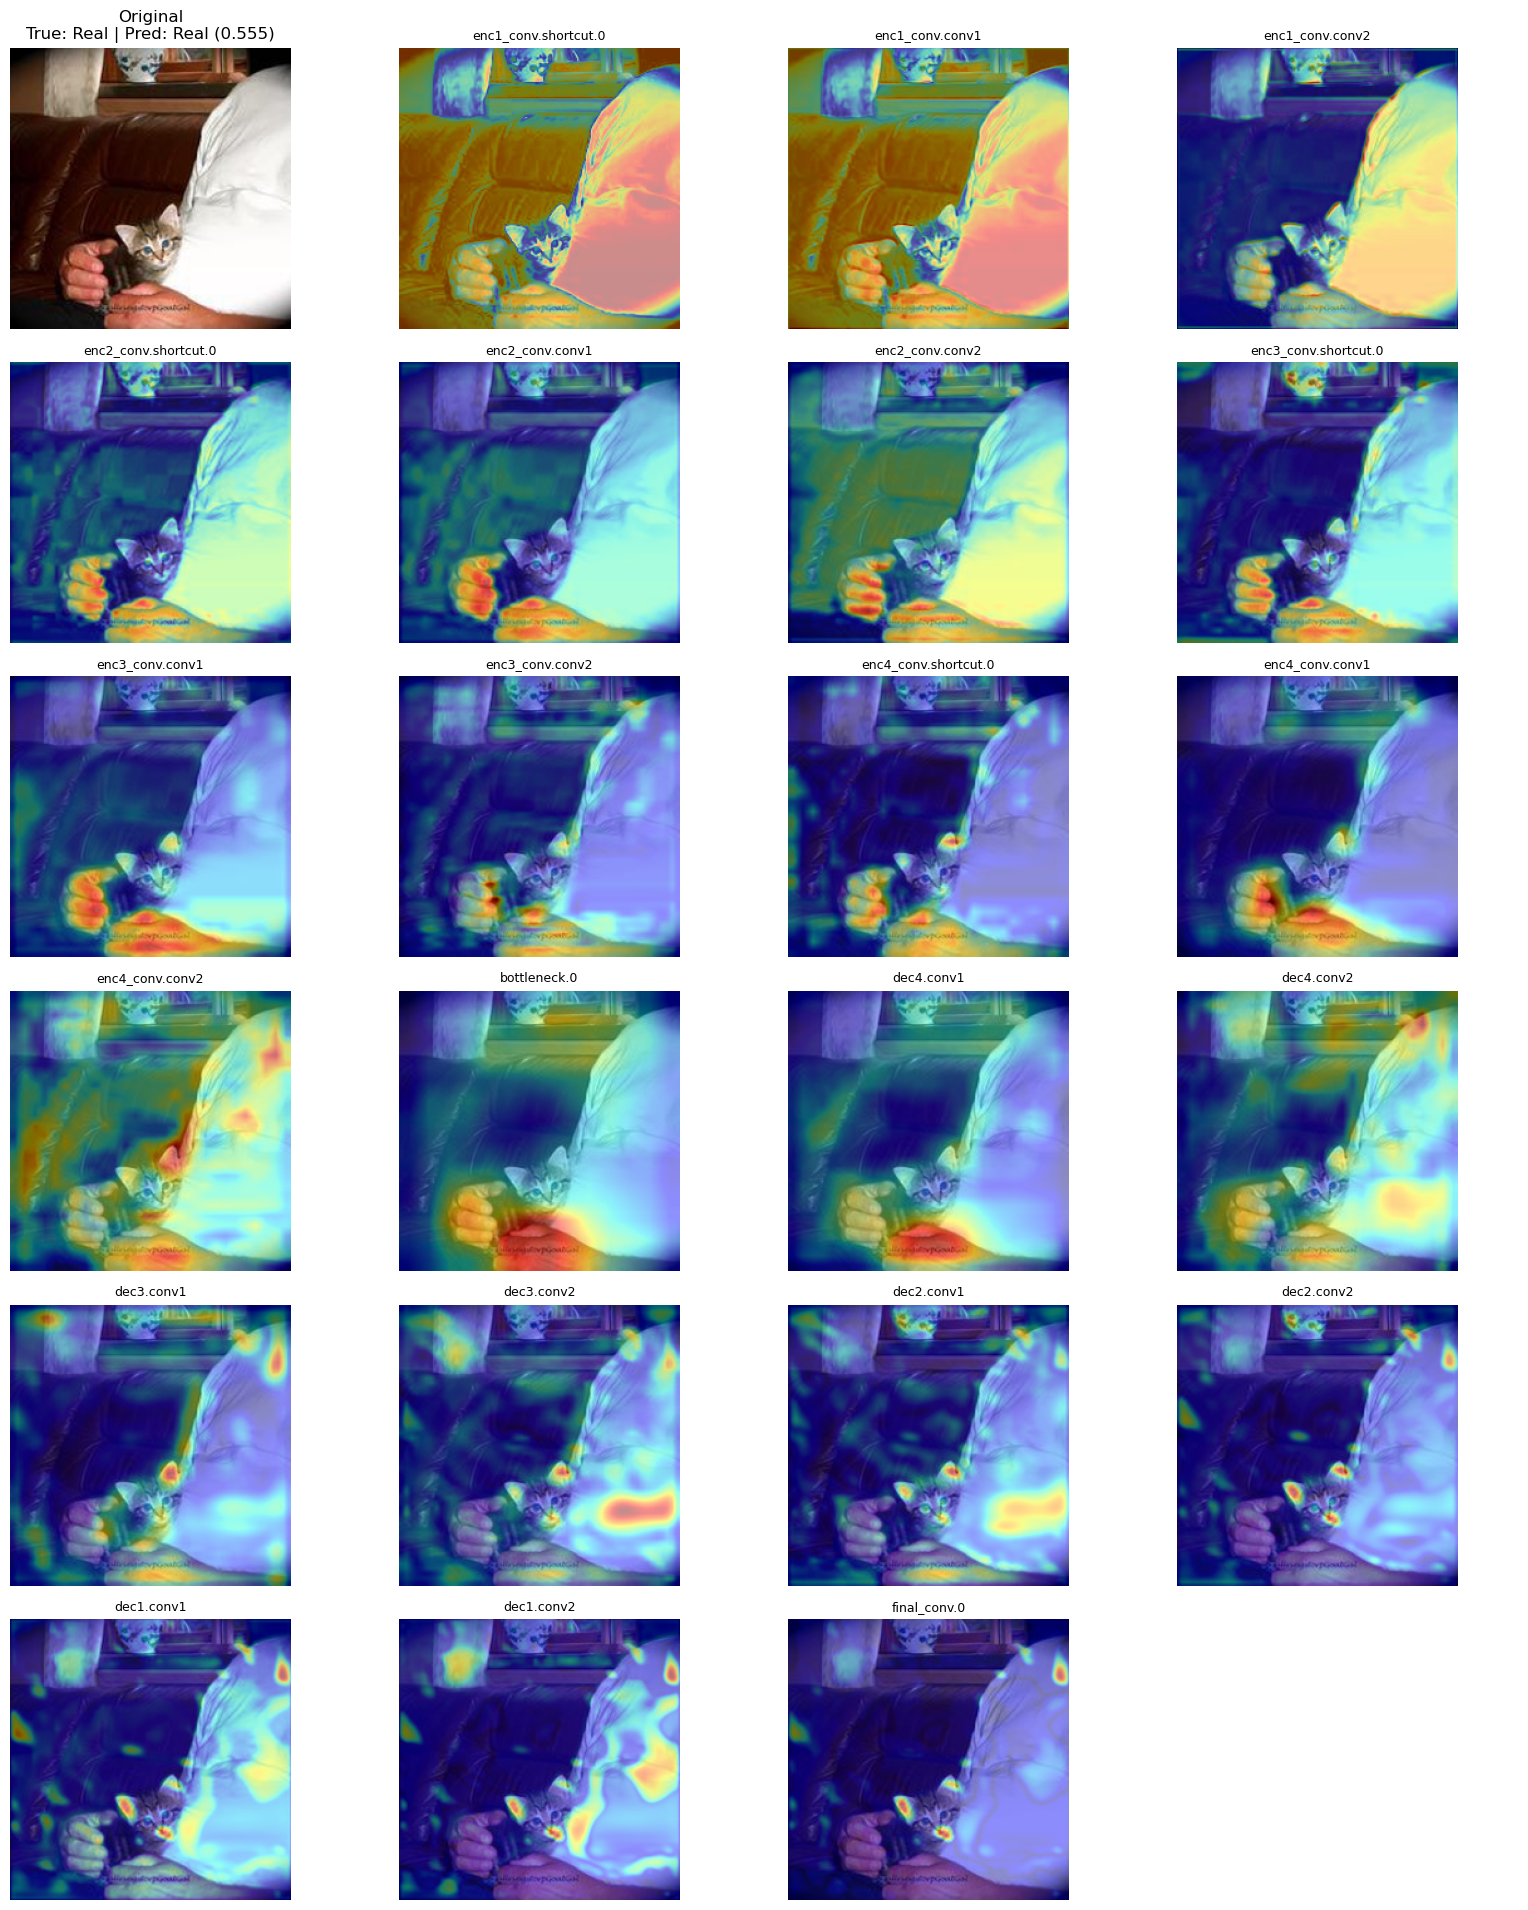

In [9]:
def get_label_name_map(hf_split, label_col_name: str):
    feat = hf_split.features.get(label_col_name, None)
    names = getattr(feat, "names", None)
    if names is not None:
        return {i: str(n) for i, n in enumerate(names)}
    return {0: "AI", 1: "Real"}


def find_first_index_for_label(hf_split, label_col_name: str, target_label: int):
    labels = hf_split[label_col_name]
    for idx, y in enumerate(labels):
        if int(y) == int(target_label):
            return idx
    raise ValueError(f"No sample found for label={target_label}")


def prepare_tandem_inputs(pil_img: Image.Image):
    x_img = normalize_tensor(pil_to_chw_float(pil_img)).unsqueeze(0).to(device)

    glcm_x = extract_glcm_96_features(pil_img)
    glcm_x = (glcm_x - glcm_mean) / glcm_std
    x_glcm = torch.from_numpy(glcm_x.astype(np.float32)).unsqueeze(0).to(device)

    forensic_x = extract_forensic_gradient_features(pil_img)
    forensic_x = (forensic_x - forensic_mean) / forensic_std
    x_forensic = torch.from_numpy(forensic_x.astype(np.float32)).unsqueeze(0).to(device)

    return x_img, x_glcm, x_forensic


def collect_cnn_conv_activations(model_obj, x_img, x_glcm, x_forensic):
    activations = {}
    hooks = []

    conv_layer_names = [
        name for name, module in model_obj.named_modules()
        if name.startswith((
            "enc1_conv",
            "enc2_conv",
            "enc3_conv",
            "enc4_conv",
            "bottleneck",
            "dec4",
            "dec3",
            "dec2",
            "dec1",
            "final_conv",
        )) and isinstance(module, nn.Conv2d)
    ]

    for name, module in model_obj.named_modules():
        if name in conv_layer_names:
            def _hook_fn(_, __, output, layer_name=name):
                activations[layer_name] = output.detach().cpu()
            hooks.append(module.register_forward_hook(_hook_fn))

    with torch.no_grad():
        logits = model_obj(x_img, x_glcm, x_forensic)
        prob_real = float(torch.softmax(logits, dim=1)[0, 1].item())

    for h in hooks:
        h.remove()

    return activations, prob_real


def activation_to_heatmap(act_tensor: torch.Tensor, out_size: int = IMG_SIZE) -> np.ndarray:
    fmap = act_tensor[0].abs().mean(dim=0).numpy()
    fmap = fmap - fmap.min()
    if fmap.max() > 0:
        fmap = fmap / fmap.max()

    fmap_t = torch.from_numpy(fmap).unsqueeze(0).unsqueeze(0).float()
    fmap_t = F.interpolate(fmap_t, size=(out_size, out_size), mode="bilinear", align_corners=False)
    return fmap_t.squeeze().numpy()


def plot_layerwise_heatmaps_for_sample(model_obj, pil_img: Image.Image, true_label: int, label_name_map: dict):
    x_img, x_glcm, x_forensic = prepare_tandem_inputs(pil_img)
    activations, prob_real = collect_cnn_conv_activations(model_obj, x_img, x_glcm, x_forensic)

    pred_label = int(prob_real >= 0.5)
    img_np = np.asarray(pil_img.convert("RGB").resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0

    layer_names = list(activations.keys())
    n_plots = len(layer_names) + 1
    n_cols = 4
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    axes[0].imshow(img_np)
    axes[0].set_title(
        f"Original\nTrue: {label_name_map.get(true_label, true_label)} | Pred: {label_name_map.get(pred_label, pred_label)} ({prob_real:.3f})"
    )
    axes[0].axis("off")

    for i, layer_name in enumerate(layer_names, start=1):
        heatmap = activation_to_heatmap(activations[layer_name], out_size=IMG_SIZE)
        axes[i].imshow(img_np)
        axes[i].imshow(heatmap, cmap="jet", alpha=0.45, interpolation="bilinear")
        axes[i].set_title(layer_name, fontsize=9)
        axes[i].axis("off")

    for j in range(n_plots, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# Pick visualization model: baseline+patch model
viz_run_id = "model_2_patch"

viz_model = loaded_models[viz_run_id]
label_name_map = get_label_name_map(ds_test, label_col)
all_labels = sorted(set(int(v) for v in ds_test[label_col]))
labels_to_show = [0, 1] if (0 in all_labels and 1 in all_labels) else all_labels[:2]

print(f"Layer-wise heatmaps using model: {viz_run_id}")
for lbl in labels_to_show:
    idx = find_first_index_for_label(ds_test, label_col, lbl)
    ex = ds_test[idx]
    img = ex["image"]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(np.asarray(img))

    print(f"\nLabel {lbl} ({label_name_map.get(lbl, lbl)}), sample index: {idx}")
    plot_layerwise_heatmaps_for_sample(viz_model, img, int(lbl), label_name_map)

In [10]:
GLCM_BASE_FEATURE_NAMES = [
    "contrast",
    "dissimilarity",
    "homogeneity",
    "asm",
    "energy",
    "correlation",
    "entropy",
    "mean_i",
    "mean_j",
    "var_i",
    "cluster_shade",
    "cluster_prominence",
]
GLCM_FEATURE_NAMES = []
for angle_idx in range(len(GLCM_ANGLES)):
    for feat_name in GLCM_BASE_FEATURE_NAMES:
        GLCM_FEATURE_NAMES.append(f"a{angle_idx}_{feat_name}")

FORENSIC_FEATURE_NAMES = [
    "grad_lambda1",
    "grad_lambda2",
    "grad_anisotropy",
    "grad_mag_mean",
    "grad_mag_std",
    "residual_variance",
    "residual_kurtosis",
    "residual_anisotropy",
]


def collect_split_tensors(loader: DataLoader, max_samples: int = 1200):
    xs_img, xs_glcm, xs_forensic, ys = [], [], [], []
    collected = 0

    for batch in loader:
        x_img = batch["image"]
        x_glcm = batch["glcm"]
        x_forensic = batch["forensic"]
        y = batch["label"]

        xs_img.append(x_img)
        xs_glcm.append(x_glcm)
        xs_forensic.append(x_forensic)
        ys.append(y)

        collected += y.size(0)
        if collected >= max_samples:
            break

    x_img = torch.cat(xs_img, dim=0)[:max_samples]
    x_glcm = torch.cat(xs_glcm, dim=0)[:max_samples]
    x_forensic = torch.cat(xs_forensic, dim=0)[:max_samples]
    y = torch.cat(ys, dim=0)[:max_samples]

    return x_img, x_glcm, x_forensic, y


def infer_probs_from_tensors(model: nn.Module, x_img: torch.Tensor, x_glcm: torch.Tensor, x_forensic: torch.Tensor, batch_size: int = 128) -> np.ndarray:
    model.eval()
    probs = []
    with torch.no_grad():
        for start in range(0, x_img.size(0), batch_size):
            end = min(start + batch_size, x_img.size(0))
            logits = model(
                x_img[start:end].to(device),
                x_glcm[start:end].to(device),
                x_forensic[start:end].to(device),
            )
            p = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            probs.append(p)
    return np.concatenate(probs)


def permutation_group_drop(model: nn.Module, x_img, x_glcm, x_forensic, y_true, seed: int = 42):
    rng = np.random.default_rng(seed)
    y_true_np = y_true.cpu().numpy()

    base_prob = infer_probs_from_tensors(model, x_img, x_glcm, x_forensic)
    base_auc = roc_auc_score(y_true_np, base_prob)

    # Shuffle all GLCM columns across samples
    idx = rng.permutation(x_glcm.size(0))
    glcm_perm_prob = infer_probs_from_tensors(model, x_img, x_glcm[idx], x_forensic)
    glcm_perm_auc = roc_auc_score(y_true_np, glcm_perm_prob)

    # Shuffle all forensic columns across samples
    idx2 = rng.permutation(x_forensic.size(0))
    forensic_perm_prob = infer_probs_from_tensors(model, x_img, x_glcm, x_forensic[idx2])
    forensic_perm_auc = roc_auc_score(y_true_np, forensic_perm_prob)

    return pd.DataFrame([
        {"group": "baseline", "auc": base_auc, "auc_drop": 0.0},
        {"group": "GLCM_all_shuffled", "auc": glcm_perm_auc, "auc_drop": base_auc - glcm_perm_auc},
        {"group": "Forensic_all_shuffled", "auc": forensic_perm_auc, "auc_drop": base_auc - forensic_perm_auc},
    ])


def permutation_feature_importance(model: nn.Module, x_img, x_glcm, x_forensic, y_true, feature_type: str, top_k: int = 15, seed: int = 42):
    rng = np.random.default_rng(seed)
    y_true_np = y_true.cpu().numpy()

    base_prob = infer_probs_from_tensors(model, x_img, x_glcm, x_forensic)
    base_auc = roc_auc_score(y_true_np, base_prob)

    rows = []
    if feature_type == "glcm":
        names = GLCM_FEATURE_NAMES
        feat = x_glcm.clone()
        for j in tqdm(range(feat.size(1)), desc="GLCM permutation", leave=False):
            feat_perm = feat.clone()
            feat_perm[:, j] = feat_perm[rng.permutation(feat_perm.size(0)), j]
            prob = infer_probs_from_tensors(model, x_img, feat_perm, x_forensic)
            auc = roc_auc_score(y_true_np, prob)
            rows.append({"feature": names[j], "auc": auc, "auc_drop": base_auc - auc})
    elif feature_type == "forensic":
        names = FORENSIC_FEATURE_NAMES
        feat = x_forensic.clone()
        for j in tqdm(range(feat.size(1)), desc="Forensic permutation", leave=False):
            feat_perm = feat.clone()
            feat_perm[:, j] = feat_perm[rng.permutation(feat_perm.size(0)), j]
            prob = infer_probs_from_tensors(model, x_img, x_glcm, feat_perm)
            auc = roc_auc_score(y_true_np, prob)
            rows.append({"feature": names[j], "auc": auc, "auc_drop": base_auc - auc})
    else:
        raise ValueError("feature_type must be 'glcm' or 'forensic'")

    imp_df = pd.DataFrame(rows).sort_values("auc_drop", ascending=False).reset_index(drop=True)
    return base_auc, imp_df.head(top_k), imp_df


x_img_s, x_glcm_s, x_forensic_s, y_s = collect_split_tensors(val_loader, max_samples=1000)
print(f"Collected subset for importance: {len(y_s)} samples")

target_models = ["model_2_patch"]
for run_id in target_models:
    if run_id not in loaded_models:
        print(f"[SKIP] {run_id} not loaded. Add corresponding weight file to run importance.")
        continue

    model = loaded_models[run_id]
    print("\n" + "#" * 72)
    print(f"Feature importance for {run_id}")
    print("#" * 72)

    group_df = permutation_group_drop(model, x_img_s, x_glcm_s, x_forensic_s, y_s, seed=SEED)
    print("Group-level importance (AUC drop):")
    display(group_df)

    base_auc_g, top_glcm, full_glcm = permutation_feature_importance(
        model, x_img_s, x_glcm_s, x_forensic_s, y_s, feature_type="glcm", top_k=15, seed=SEED
    )
    print(f"Base AUC before GLCM permutations: {base_auc_g:.4f}")
    print("Top 15 GLCM features by AUC drop:")
    display(top_glcm)

    base_auc_f, top_forensic, full_forensic = permutation_feature_importance(
        model, x_img_s, x_glcm_s, x_forensic_s, y_s, feature_type="forensic", top_k=8, seed=SEED
    )
    print(f"Base AUC before forensic permutations: {base_auc_f:.4f}")
    print("Forensic feature importance by AUC drop:")
    display(top_forensic)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(top_glcm["feature"][::-1], top_glcm["auc_drop"][::-1])
    axes[0].set_title(f"{run_id}: Top GLCM importance")
    axes[0].set_xlabel("AUC drop after permutation")

    axes[1].barh(top_forensic["feature"][::-1], top_forensic["auc_drop"][::-1])
    axes[1].set_title(f"{run_id}: Forensic importance")
    axes[1].set_xlabel("AUC drop after permutation")

    plt.tight_layout()
    plt.show()

Collected subset for importance: 250 samples

########################################################################
Feature importance for model_2_patch
########################################################################
Group-level importance (AUC drop):


,group,auc,auc_drop
0,baseline,0.911629,0.000000
1,GLCM_all_shuffled,0.902536,0.009093
2,Forensic_all_shuffled,0.875704,0.035925


GLCM permutation:   0%|          | 0/96 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Optional: detailed classification report for the best available model on test
if all_results:
    best_run = summary_df.iloc[0]["run_id"]
    y_true = all_results[best_run]["test"]["y_true"]
    y_pred = all_results[best_run]["test"]["y_pred"]
    label_names = ["Real", "AI"]

    print(f"Best model detailed report: {best_run}")
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

In [ ]:
# Minimal architecture smoke test for the corrected tandem model.
# This validates the decoder skip shapes without running dataset loading.
model_smoke = CNNWithTextureFusion(num_classes=2, glcm_dim=GLCM_FEATURE_DIM, forensic_dim=FORENSIC_FEATURE_DIM).to(device)
model_smoke.eval()

x_img = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device)
x_glcm = torch.randn(2, GLCM_FEATURE_DIM, device=device)
x_forensic = torch.randn(2, FORENSIC_FEATURE_DIM, device=device)

with torch.no_grad():
    logits = model_smoke(x_img, x_glcm, x_forensic)

print("Smoke test logits shape:", tuple(logits.shape))
assert logits.shape == (2, 2), f"Unexpected output shape: {tuple(logits.shape)}"

Smoke test logits shape: (2, 2)
